# 6. MusSkl diff 7group

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{outdir}/DMR_3group_{version}group.mcds'`  ·  _mC matrix (mcds)_
- `f'{loopdir}merged_loop.hdf'`  ·  _loop calls_
- `f'{loopdir}loop_Q.hdf'`  ·  _loop calls_
- `f'{loopdir}loop_T.hdf'`  ·  _loop calls_
- `f'{outdir}5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{outdir}hg38.main.10kbin.dmr.7group_{version}.txt'`  ·  _DMR_
- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{cooldir}{ct}.Q.cool'`  ·  _contacts (cool)_
- `'Mus-Skl/SklMus-mc_dmr'`  ·  _DMR_
- `'Mus-Skl/Mus-Skl_DMR.mcds'`  ·  _mC matrix (mcds)_
- `'Mus-Skl/cell_3971_DMR_8group_mCG.hdf'`  ·  _DMR_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
import cooler
from ALLCools.mcds import RegionDS,MCDS
from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

# mpl.use('agg')
mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/Mus-Skl/'
version = 'new'
dmrdir = f'{outdir}DMR_7group_{version}/'
loopdir = f'{outdir}diffloop_7group_{version}/'
# outdir = f'{ENTEX_ROOT}/analysis/pairwise_prediction/'


In [3]:
ct = 'Mus-Skl'


In [4]:
# def rename_cluster(xx):
#     yy = xx.replace('-',' ').replace('c', 'C')
#     yy = yy.replace('0', '-Stem').replace('1', '-Fast').replace('2', '-Slow')
#     return yy
def rename_cluster(xx):
    yy = xx.replace('-','/').replace('mc','').replace('3c','')
    yy = yy.replace('0', 'Stem').replace('1', 'Fast').replace('2', 'Slow')
    return yy


In [6]:
mcds = MCDS.open(f'{outdir}/DMR_3group_{version}group.mcds', var_dim='DMR')
mcds['DMR_frac_da'] = mcds.sel({'count_type':'mc'})['DMR_da'] / mcds.sel({'count_type':'cov'})['DMR_da']
dmr_data = mcds['DMR_frac_da'].to_pandas().fillna(1).T


In [9]:
res = 10000


## L2any diff loop

In [10]:
loopall = pd.read_hdf(f'{loopdir}merged_loop.hdf', key='data')
loopq = pd.read_hdf(f'{loopdir}loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{loopdir}loop_T.hdf', key='data')


In [11]:
from scipy.stats import norm, zscore

thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)
fdrthres = 1e-1


1.9599639845400545 1.0364333894937898


In [12]:
# loopall = pd.read_hdf(f'{loopdir}merged_loop.hdf', key='data')
statfilter = (zscore(loopall['Qanova'])>thres2) & (zscore(loopall['Tanova'])>thres2)
fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
# selloop = statfilter & fdrfilter
selloop = fdrfilter
print(statfilter.sum(), fdrfilter.sum(), selloop.sum())


6835 27093 27093


In [13]:
diffloop = loopall.loc[selloop, [0,1,4]]
diffloop[[1, 4]] = diffloop[[1, 4]] // res
diffloop = diffloop.reset_index()
diffloop


,index,0,1,4
0,2,chr1,179,188
1,20,chr1,797,824
2,24,chr1,797,831
3,25,chr1,797,832
4,26,chr1,797,833
...,...,...,...,...
27088,116583,chr22,4614,4624
27089,116584,chr22,4614,4625
27090,116585,chr22,4614,4626
27091,116593,chr22,4615,4625


In [14]:
data = pd.read_csv(f'{outdir}hg38.main.10kbin.dmr.7group_{version}.txt', sep='\t', header=None, index_col=None)
# data[6] = data[6].str.split('.').str[0]
data[3] = data[0] + '-' + (data[1] // res).astype(str)
bin2dmr = {xx:[] for xx in data[3].values}
data = data[data[7]!='.']
for xx,yy in data[[3,7]].values:
    bin2dmr[xx].append(yy)
    

In [15]:
selloop = []
seldmr = []
for loop in diffloop[[0, 1, 4, 'index']].values:
    xx = f'{loop[0]}-{loop[1]}'
    yy = f'{loop[0]}-{loop[2]}'
    zz = bin2dmr[xx] + bin2dmr[yy]
    if len(zz)>0:
        selloop.append(np.repeat([loop[3]], len(zz)))
        seldmr.append(zz)

selloop = np.concatenate(selloop)
seldmr = np.concatenate(seldmr)
print(len(selloop), len(seldmr))


62580 62580


In [16]:
leg_3c = pd.Index(['mc1-3c1', 'mc2-3c1', 'mc0-3c1', 
                   'mc0-3c0', 
                   'mc0-3c2', 'mc1-3c2', 'mc2-3c2'])
leg_cg = pd.Index(['mc1-3c1', 'mc1-3c2', 'mc0-3c1', 
                   'mc0-3c0', 
                   'mc0-3c2', 'mc2-3c1', 'mc2-3c2'])
leg_share = pd.Index(['mc1-3c1', 'mc0-3c0', 'mc2-3c2'])


In [18]:
from sklearn.cluster import KMeans

def order_row(data, nc):
    data = data.reset_index(drop=True)
    
    # Perform KMeans clustering    
    kmeans = KMeans(n_clusters=nc, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(data)

    # Create a new dataframe with cluster labels
    cluster_df = pd.DataFrame({'Cluster': clusters}, index=data.index)

    # Sort the data by cluster and plot the heatmap
    merged_data = pd.concat([data, cluster_df], axis=1).groupby(by='Cluster').mean()
    cg = sns.clustermap(merged_data, cmap='vlag', metric='cosine', figsize=(6,4), col_cluster=False)
    
    rorder = cg.dendrogram_row.reordered_ind.copy()
    # leg = merged_data.index[rorder]
    leg = [10,11,0,1,8,6,5,3,7,2,4,9,12]
    count = pd.Series(clusters).value_counts().loc[leg]
    # sorted_data = pd.concat([data[clusters==i] for i in leg], axis=0)
    rorder = np.concatenate([data.index[clusters==i] for i in leg])
    
    return rorder, count, cluster_df


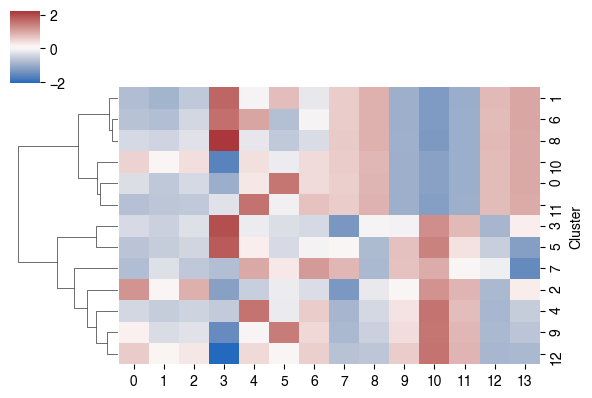

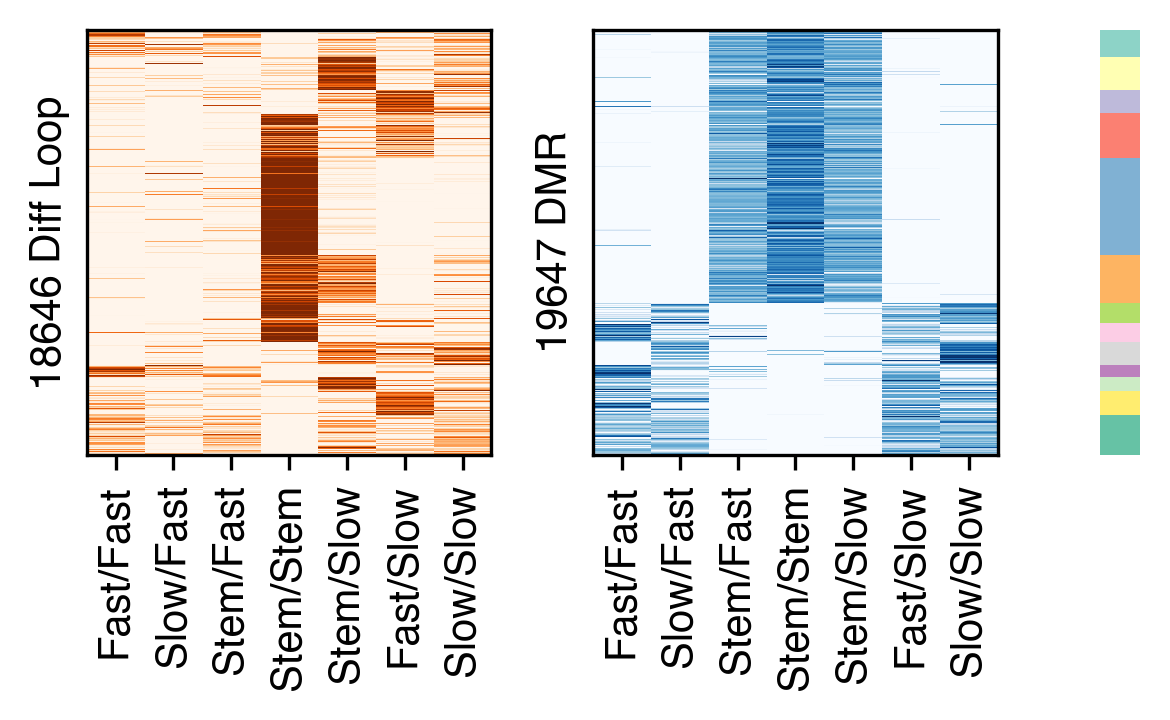

In [21]:
nc = 13
group_palette = sns.color_palette('Set3', 12) + sns.color_palette('Set2', nc-12)

tmp = np.concatenate([zscore(loopq.loc[selloop, leg_3c].values, axis=1), 
                      zscore(dmr_data.loc[seldmr, leg_3c].values, axis=1)], axis=1)
rorder, count, label = order_row(pd.DataFrame(tmp), nc=nc)
tmp3c = zscore(loopq.loc[selloop, leg_3c], axis=1)
tmpcg = zscore(dmr_data.loc[seldmr, leg_3c], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(4,2.5), dpi=300, sharey='all', 
                         gridspec_kw={'width_ratios': [10, 10, 1]})

ax = axes[0]
# ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
#           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
ax.imshow(tmp3c.iloc[rorder], cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
# sns.despine(ax=ax, left=True, bottom=True)
# ax.set_xticks(np.arange(data.shape[1]))
# ax.set_xticklabels(data.columns[corder], rotation=90)
ax.set_xticks(np.arange(loopq.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selloop).shape[0]} Diff Loop')

ax = axes[1]
ax.imshow(tmpcg.iloc[rorder], cmap='Blues_r', aspect='auto', 
          vmin=-2, vmax=0, interpolation='none', rasterized=True)
# sns.despine(ax=ax, left=True, bottom=True)
ax.set_xticks(np.arange(dmr_data.shape[1]))
ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
# selidx = np.arange(0, nrow, nrow//15)
# ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
ax.set_yticks([])
# ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
ax.set_ylabel(f'{np.unique(seldmr).shape[0]} DMR')

ax = axes[2]
offset = [0] + list(count.cumsum())
ax.axis('off')
for k in range(nc):
    rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, 
                             edgecolor='none', facecolor=group_palette[k])
    ax.add_patch(rect)

fig.tight_layout()
fig.savefig(f'{outdir}plot/{ct}_mc3c_DMR_loop_7group_{version}_fdr_cgkmeans_heatmap.pdf', transparent=True)


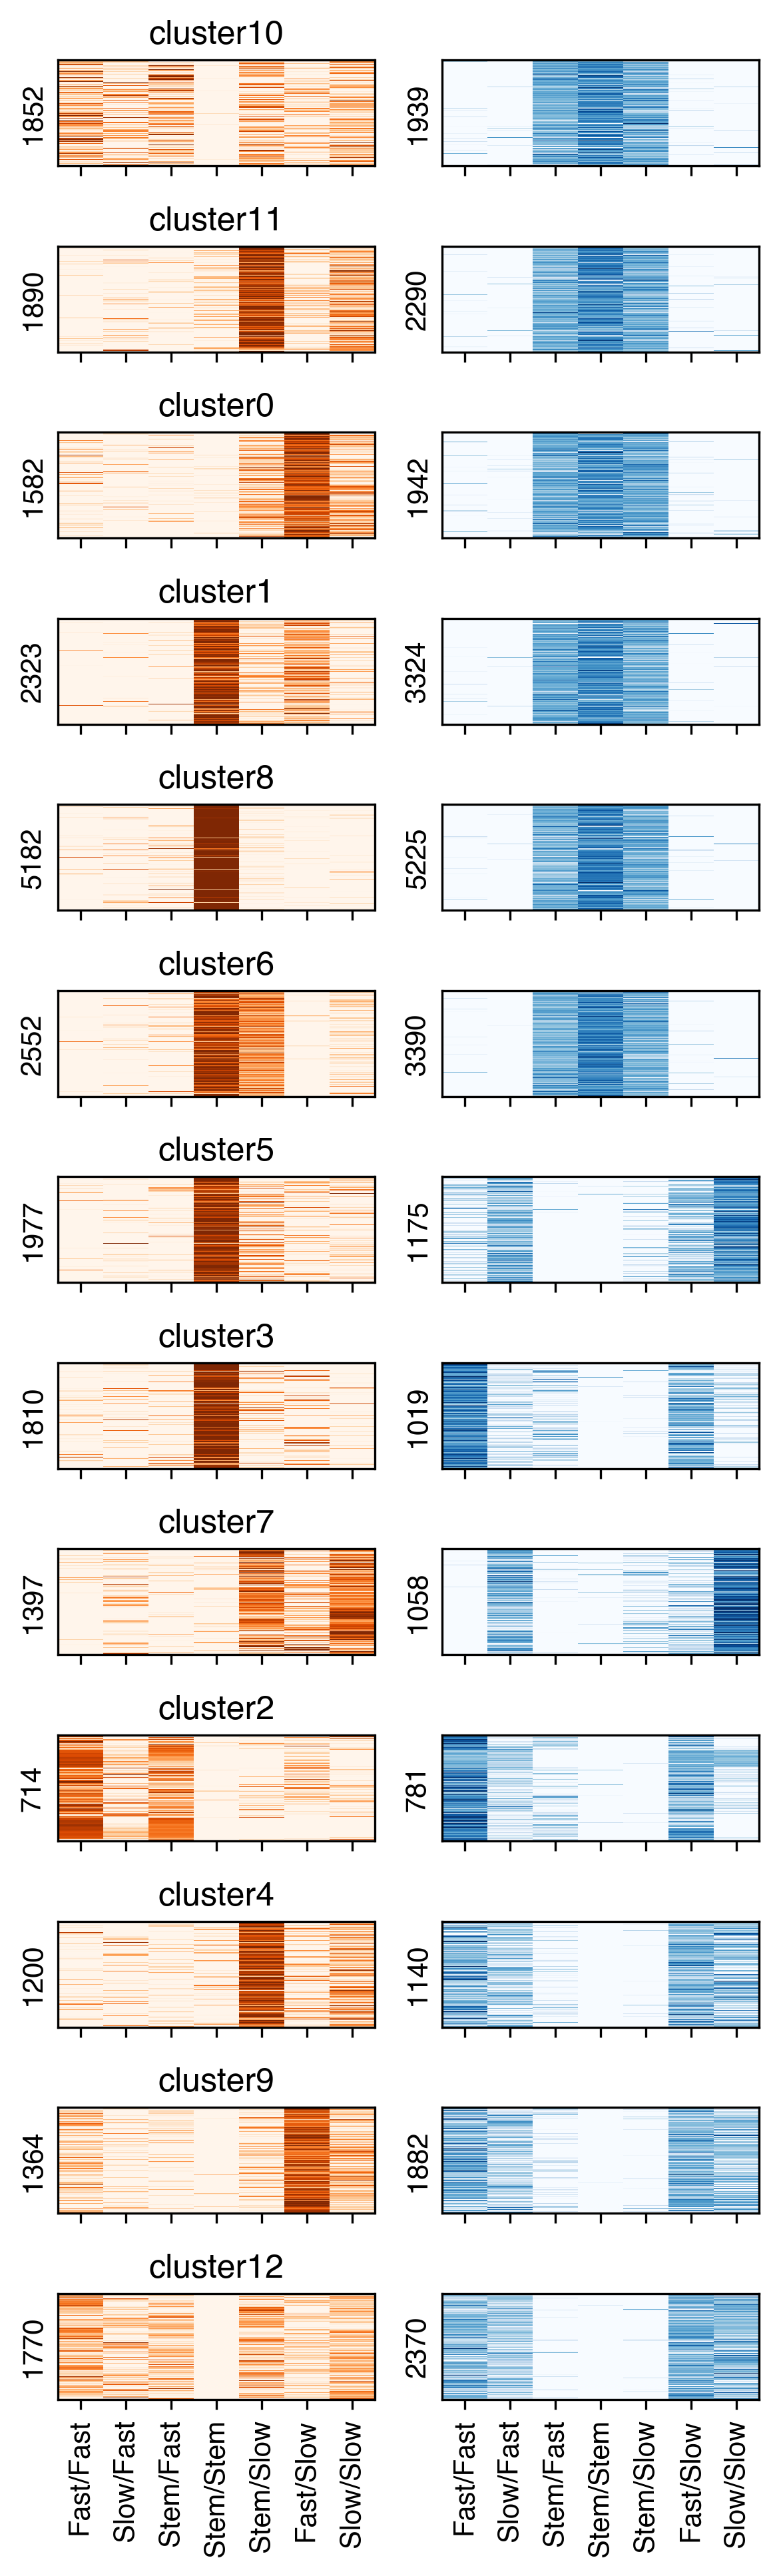

In [22]:
fig, axes = plt.subplots(nc, 2, figsize=(4,nc), dpi=300, sharex='all', sharey='row')

for i in range(nc):
    ax = axes[i,0]
    selp = (label==count.index[i]).values[:,0]
    # ax.imshow(data.loc[dmr_gene_map.index].iloc[rorder_mc].iloc[:, corder_mc], 
    #           cmap='Greens_r', aspect='auto', interpolation='none', rasterized=True)
    ax.imshow(tmp3c.values[selp], cmap='Oranges', aspect='auto', 
              interpolation='none', rasterized=True, vmin=0, vmax=2)
    # sns.despine(ax=ax, left=True, bottom=True)
    # ax.set_xticks(np.arange(data.shape[1]))
    # ax.set_xticklabels(data.columns[corder], rotation=90)
    ax.set_xticks(np.arange(loopq.shape[1]))
    ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
    ax.set_yticks([])
    ax.set_ylabel(f'{np.unique(selloop[selp]).shape[0]}')
    ax.set_title(f'cluster{count.index[i]}')

    ax = axes[i,1]
    ax.imshow(tmpcg.values[selp], cmap='Blues_r', aspect='auto', 
              vmin=-2, vmax=0, interpolation='none', rasterized=True)
    # sns.despine(ax=ax, left=True, bottom=True)
    ax.set_xticks(np.arange(dmr_data.shape[1]))
    ax.set_xticklabels(leg_3c.map(rename_cluster), rotation=90)
    # selidx = np.arange(0, nrow, nrow//15)
    # ax.tick_params(axis='y', right=True, left=False, labelright=True, labelleft=False)
    ax.set_yticks([])
    # ax.set_yticklabels(pd.Index(seldmr).map(ens2gene).values[selidx])
    ax.set_ylabel(f'{np.unique(seldmr[selp]).shape[0]}')

fig.tight_layout()
fig.savefig(f'{outdir}plot/{ct}_mc3c_DMR_loop_7group_{version}_fdr_cgkmeans_heatmap_percluster.pdf', transparent=True)
# count = pd.Series(label).value_counts().sort_index()
# ax.set_yticks(count.cumsum()-0.5)
# ax.set_yticklabels(count.index)


In [31]:
leg = pd.Index(['mc1-3c1', 'mc1-3c2', 'mc2-3c2', 'mc2-3c1'])
cooldir = f'{indir}analysis/Mus-Skl/cool_{version}/'
allcdir = f'{indir}analysis/Mus-Skl/allc_{version}/'

In [32]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]


In [33]:
# MYL3 MYL2 MYL11
# MYH1 MYH2 MYH7 MYHAS
gtmp = 'MYH7'
lslop, rslop = 500000, 500000

chrom, start, end, strand = gene_meta.loc[gene_meta['gene_name']==gtmp, ['chrom', 'start', 'end', 'strand']].iloc[0]
if strand=='+':
    tss = start
else:
    tss = end

ll, rr = (tss - lslop), (tss + rslop)
print(chrom, ll, rr)


chr14 22935660 23935660


In [34]:
resl = 10000
loopl, loopr = (ll//resl), (rr//resl)
print(loopl, loopr)

2293 2393


In [35]:
## Load cell type Q
import cooler
from scipy import ndimage as nd

dstall = []
for ct in leg:
    cool = cooler.Cooler(f'{cooldir}{ct}.Q.cool')
    Q = cool.matrix(balance=False, sparse=True).fetch(chrom).tocsr()
    tmp = Q[loopl:loopr, loopl:loopr].toarray()
    tmp = nd.rotate(tmp, 45, order=0, reshape=True, prefilter=False, cval=0)
    dstall.append(tmp)
    print(ct)
    

mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


In [36]:
import pysam
from scipy.sparse import csr_matrix


In [37]:
def load_allc(ct, chrom, start, end):
    global indir
    allc_path = f'{allcdir}{ct}.CGN-Merge.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start+1, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start-1)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])

start = loopl * resl
end = loopr * resl
data_mc_row, data_mc_col, data_mc_data = [], [], []
data_cov_row, data_cov_col, data_cov_data = [], [], []
for i,ct in enumerate(leg):
    idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
    posfilter = np.ones(len(idx)).astype(bool)
    # for bed in rm_list:
    #     for xx,yy in bed[chrom]:
    #         posfilter[np.logical_and(idx>=xx, idx<=yy)] = False
    # print(np.sum(posfilter)/len(posfilter))
    # idx = idx[posfilter]
    # tmp_mc = tmp_mc[posfilter]
    # tmp_cov = tmp_cov[posfilter]
    data_mc_row.extend(np.zeros(len(idx))+i)
    data_mc_col.extend(idx)
    data_mc_data.extend(tmp_mc)
    data_cov_row.extend(np.zeros(len(idx))+i)
    data_cov_col.extend(idx)
    data_cov_data.extend(tmp_cov)
    print(ct)

data_mc_cg = csr_matrix((data_mc_data, (data_mc_row, data_mc_col)), shape=[len(leg), end-start])
data_cov_cg = csr_matrix((data_cov_data, (data_cov_row, data_cov_col)), shape=[len(leg), end-start])


[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c1.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c1.CGN-Merge.allc.tsv.gz.tbi


mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


In [38]:
colors = {'CG':sns.color_palette('Blues',1), 'CH':sns.color_palette('Purples',1)}

MYH7


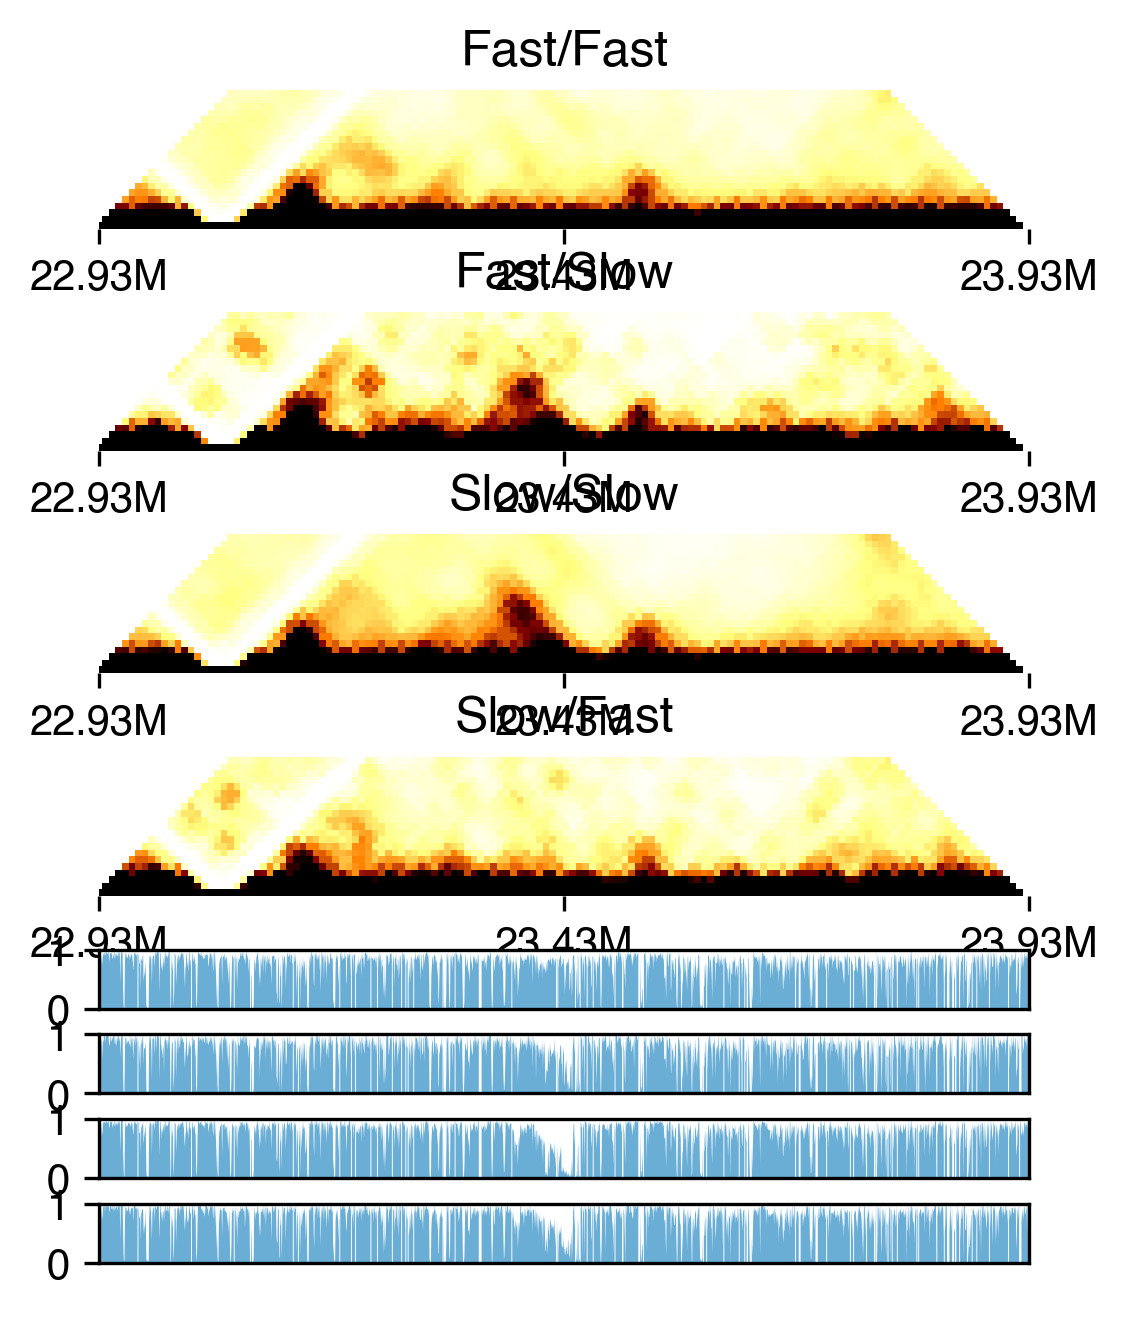

In [40]:
print(gtmp)
resm = 500
fig, axes = plt.subplots(len(leg)*2, 1, figsize=(4, np.sum(np.repeat([2,0.6],len(leg)).tolist())/2), 
                         gridspec_kw={'height_ratios': np.repeat([2,0.6],len(leg)).tolist()}, dpi=300)

for i in range(len(leg)):
    ax = axes[i]
    ax.set_title(leg.map(rename_cluster)[i])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    img = ax.imshow(dstall[i], cmap='afmhot_r', vmin=0, vmax=0.02, 
                    interpolation='none', rasterized=True)
    h = len(dstall[i])
    ax.set_ylim([0.5*h, 0.35*h])
    ax.set_xlim([0, h])
    ax.set_yticks([])
    ax.set_yticklabels([])
    # ax.scatter((tmpl[:, 0]+tmpl[:, 1])/np.sqrt(2), 0.5*h-(tmpl[:, 1]-tmpl[:, 0])/np.sqrt(2), 
    #        alpha=0.1, s=10, marker='D', edgecolors='c', color='none')
    ax.set_xlim([0, (loopr-loopl-1)*np.sqrt(2)])
    ax.set_xticks(np.sqrt(2)*np.arange(0, loopr-loopl+1, 50))
    ax.set_xticklabels([])
    ax.set_xticklabels([f'{(xx+loopl)/100}M' for xx in np.arange(0, loopr-loopl+1, 50)])

    ax = axes[len(leg)+i]
    mc_tmp = data_mc_cg[i].toarray()[0]
    cov_tmp = data_cov_cg[i].toarray()[0]
    tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
    x = np.arange(len(tmp))
    nbins = tmp.shape[0]
    ax.set_xlim([0, nbins])
    ax.set_xticks([])
    ax.set_ylim([0, 1])
    ax.set_yticks([0, 1])
    ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CG'], interpolate=True)
    
#     ax = axes[len(leg)*2+i]
#     mc_tmp = data_mc_ch[i].toarray()[0]
#     cov_tmp = data_cov_ch[i].toarray()[0]
#     tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
#     x = np.arange(len(tmp))
#     nbins = tmp.shape[0]
#     ax.set_xlim([0, nbins])
#     ax.set_xticks([])
#     ax.set_ylim([0.005, 0.015])
#     ax.set_yticks([0.005, 0.015])
#     ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CH'], interpolate=True)
    
# fig.tight_layout()
fig.savefig(f'Mus-Skl/Mus-Skl_fastslow_browser_{gtmp}_{version}.pdf', transparent=True)


In [41]:
def load_allc(ct, chrom, start, end):
    global indir
    allc_path = f'{allcdir}{ct}.CGN-Merge.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start+1, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            # if context[1] in 'GN':
            #     continue
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start-1)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])

def load_multi_allc(chrom, start, end):
    global leg
    data_mc_row, data_mc_col, data_mc_data = [], [], []
    data_cov_row, data_cov_col, data_cov_data = [], [], []
    for i,ct in enumerate(leg):
        idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
        posfilter = np.ones(len(idx)).astype(bool)
        data_mc_row.extend(np.zeros(len(idx))+i)
        data_mc_col.extend(idx)
        data_mc_data.extend(tmp_mc)
        data_cov_row.extend(np.zeros(len(idx))+i)
        data_cov_col.extend(idx)
        data_cov_data.extend(tmp_cov)
        print(ct)

    data_mc_cg = csr_matrix((data_mc_data, (data_mc_row, data_mc_col)), shape=[len(leg), end-start])
    data_cov_cg = csr_matrix((data_cov_data, (data_cov_row, data_cov_col)), shape=[len(leg), end-start])
    return data_mc_cg, data_cov_cg


[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c1.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c1.CGN-Merge.allc.tsv.gz.tbi


mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c1.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc1-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c2.CGN-Merge.allc.tsv.gz.tbi
[W::hts_idx_load3] The index file is older than the data file: /large_storage/zhoulab/zhoujt/project/ENTEx/analysis/Mus-Skl/allc_new/mc2-3c1.CGN-Merge.allc.tsv.gz.tbi


mc1-3c1
mc1-3c2
mc2-3c2
mc2-3c1


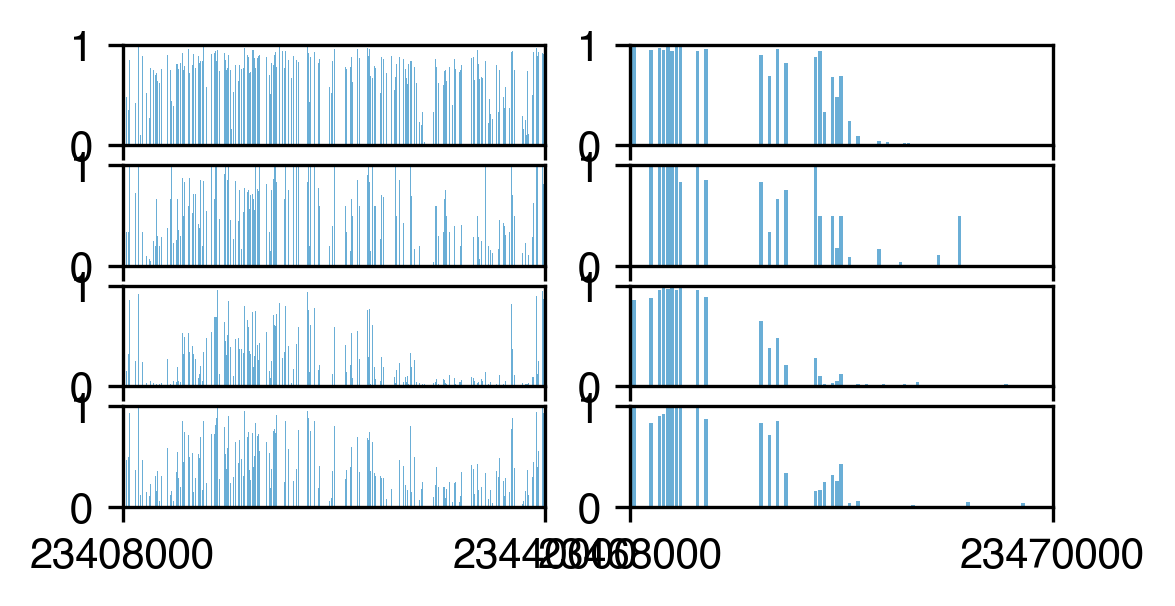

In [42]:
region_list = [['chr14', 23408000, 23440000], 
               ['chr14', 23468000, 23470000]]

fig, axes = plt.subplots(len(leg), len(region_list), figsize=(2*len(region_list), 2), sharex='col', dpi=300)
for k, (chrom, start, end) in enumerate(region_list):
    data_mc_cg, data_cov_cg = load_multi_allc(chrom, start, end)
    nbins = 500
    resm = max((end - start) // nbins, 20)
    for i in range(len(leg)):
        ax = axes[i, k]
        mc_tmp = data_mc_cg[i].toarray()[0][:(resm*nbins)]
        cov_tmp = data_cov_cg[i].toarray()[0][:(resm*nbins)]
        tmp = mc_tmp.reshape((-1, resm)).sum(axis=1) / cov_tmp.reshape((-1, resm)).sum(axis=1)
        nbins = tmp.shape[0]
        tmp[np.isnan(tmp)] = 0
        x = np.arange(len(tmp))
        ax.set_xlim([0, nbins])
        ax.set_xticks([])
        ax.set_ylim([0, 1])
        ax.set_yticks([0, 1])
        x = x[tmp>0]
        tmp = tmp[tmp>0]
        ax.bar(x, tmp, color=colors['CG'])
        # ax.fill_between(x, tmp, 0, where=tmp >= 0, facecolor=colors['CG'], interpolate=False)
    ax.set_xticks([0, nbins])
    ax.set_xticklabels([start, start+resm*nbins])
    
# fig.tight_layout()
fig.savefig(f'Mus-Skl/Mus-Skl_fastslow_browser_{gtmp}_mczoomin_{version}.pdf', transparent=True)
